In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

In [6]:
from data import load_and_prepare_panel

panel = load_and_prepare_panel()

print("Shape:", panel.shape)
print("Treated geos:", panel.loc[panel["treated"] == 1, "geo"].unique())
print("Control geos:", panel.loc[panel["treated"] == 0, "geo"].nunique())
print("Date range:", panel["date"].min(), "→", panel["date"].max())

Shape: (10800, 8)
Treated geos: <ArrowStringArray>
['G01', 'G07', 'G09', 'G41', 'G45', 'G56']
Length: 6, dtype: str
Control geos: 54
Date range: 2026-01-05 00:00:00 → 2026-07-03 00:00:00


In [7]:
import pandas as pd

pre = panel[panel["post"] == 0]
post = panel[panel["post"] == 1]

summary = pd.DataFrame({
    "treated_pre_revenue": [pre.loc[pre["treated"] == 1, "revenue"].mean()],
    "control_pre_revenue": [pre.loc[pre["treated"] == 0, "revenue"].mean()],
    "treated_post_revenue": [post.loc[post["treated"] == 1, "revenue"].mean()],
    "control_post_revenue": [post.loc[post["treated"] == 0, "revenue"].mean()],
    "treated_pre_spend": [pre.loc[pre["treated"] == 1, "spend"].mean()],
    "control_pre_spend": [pre.loc[pre["treated"] == 0, "spend"].mean()],
    "treated_post_spend": [post.loc[post["treated"] == 1, "spend"].mean()],
    "control_post_spend": [post.loc[post["treated"] == 0, "spend"].mean()],
}).T.rename(columns={0: "mean"})

print(summary.round(2))

                          mean
treated_pre_revenue   78062.52
control_pre_revenue   40595.66
treated_post_revenue  93924.89
control_post_revenue  44610.38
treated_pre_spend      9342.76
control_pre_spend      4958.93
treated_post_spend    10330.60
control_post_spend     5464.42


In [8]:
treated_pre = pre.loc[pre["treated"] == 1, "revenue"].mean()
treated_post = post.loc[post["treated"] == 1, "revenue"].mean()
control_pre = pre.loc[pre["treated"] == 0, "revenue"].mean()
control_post = post.loc[post["treated"] == 0, "revenue"].mean()

treated_change = treated_post - treated_pre
control_change = control_post - control_pre
naive_did = treated_change - control_change

print(f"Treated revenue change: {treated_change:,.2f}")
print(f"Control revenue change: {control_change:,.2f}")
print(f"Naive DiD: {naive_did:,.2f}")

Treated revenue change: 15,862.37
Control revenue change: 4,014.72
Naive DiD: 11,847.65


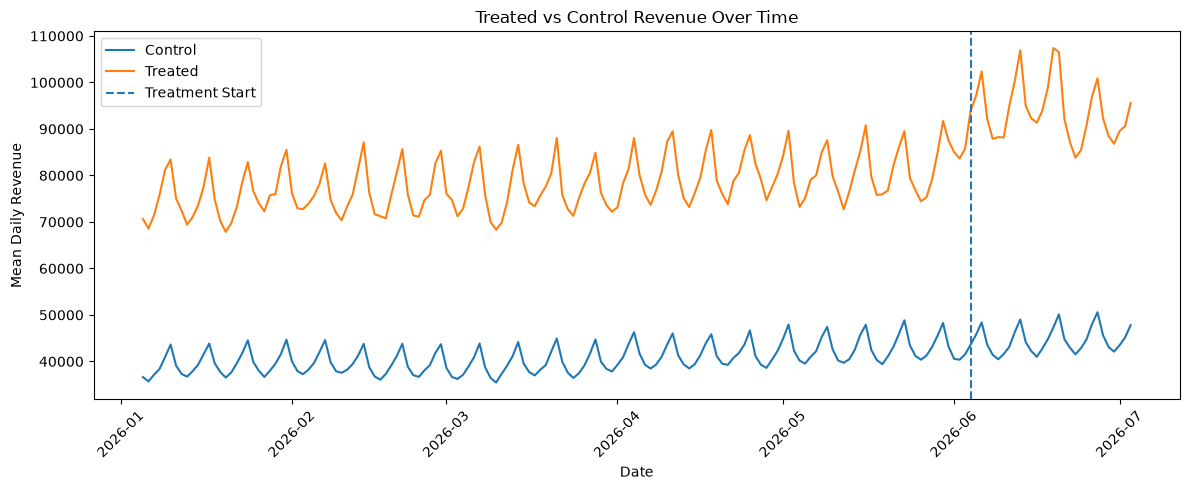

In [9]:
import matplotlib.pyplot as plt

daily = (
    panel.groupby(["date", "treated"])["revenue"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 5))

for treated, label in [(0, "Control"), (1, "Treated")]:
    subset = daily[daily["treated"] == treated]
    plt.plot(subset["date"], subset["revenue"], label=label)

plt.axvline(
    pd.Timestamp("2026-06-04"),
    linestyle="--",
    label="Treatment Start"
)

plt.xlabel("Date")
plt.ylabel("Mean Daily Revenue")
plt.title("Treated vs Control Revenue Over Time")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

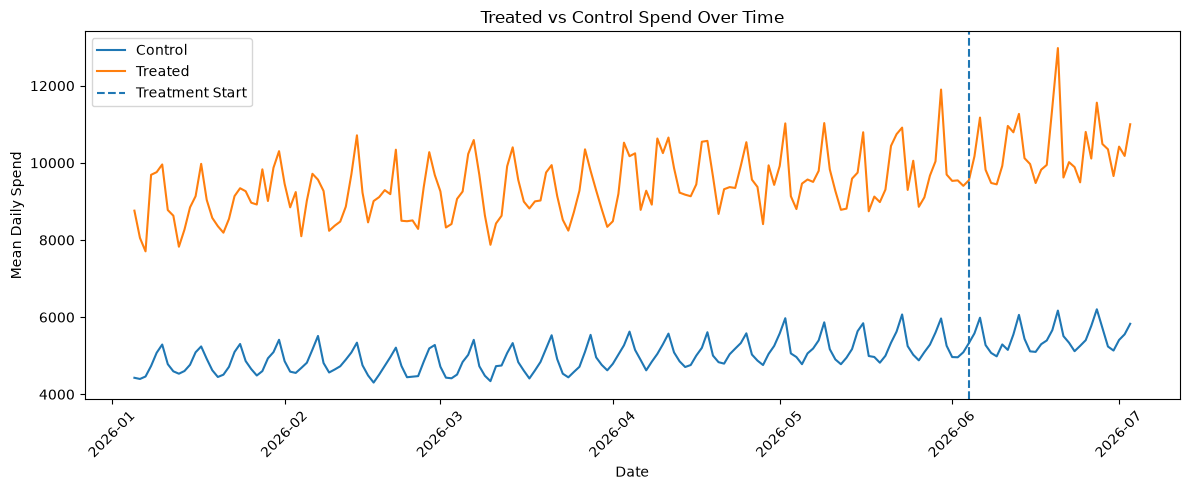

In [10]:
daily_spend = (
    panel.groupby(["date", "treated"])["spend"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 5))

for treated, label in [(0, "Control"), (1, "Treated")]:
    subset = daily_spend[daily_spend["treated"] == treated]
    plt.plot(subset["date"], subset["spend"], label=label)

plt.axvline(
    pd.Timestamp("2026-06-04"),
    linestyle="--",
    label="Treatment Start"
)

plt.xlabel("Date")
plt.ylabel("Mean Daily Spend")
plt.title("Treated vs Control Spend Over Time")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

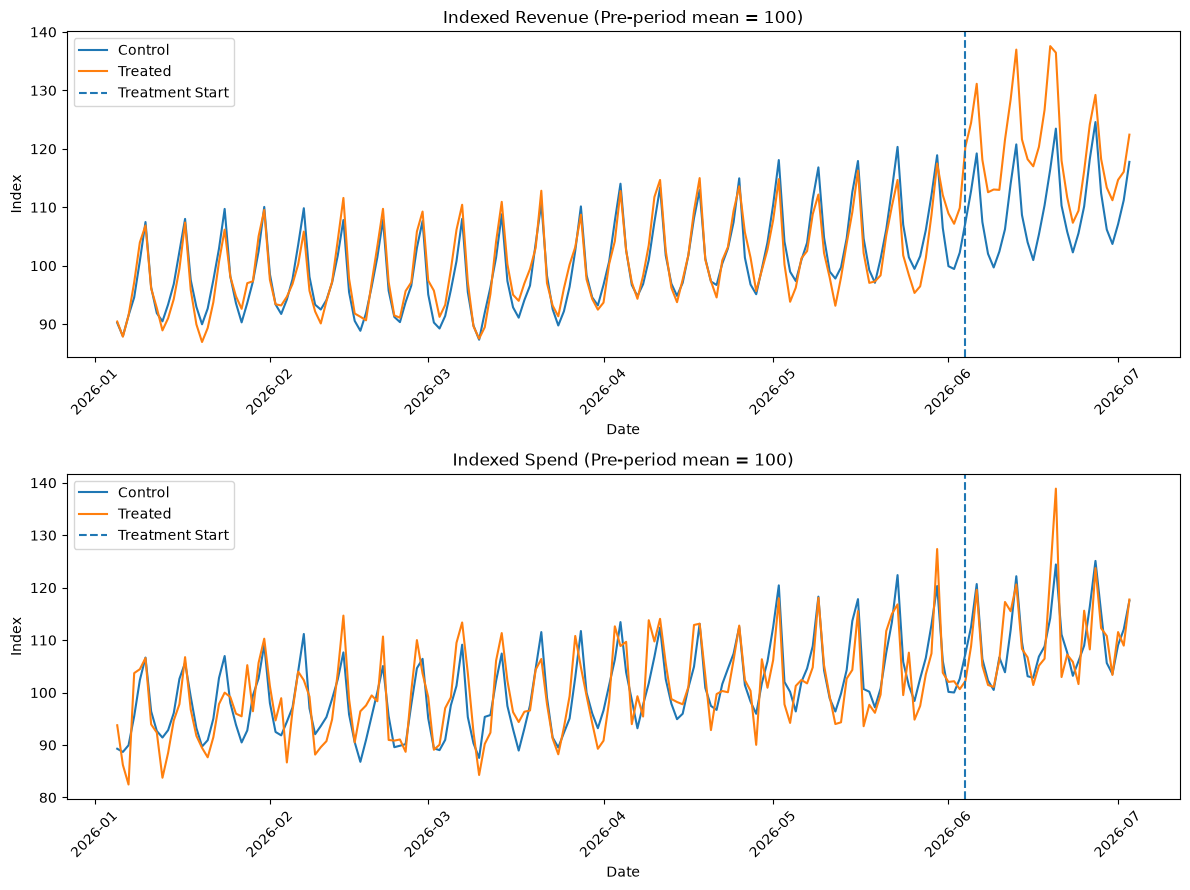

In [11]:
daily = panel.groupby(["date", "treated"])[["revenue", "spend"]].mean().reset_index()

for col in ["revenue", "spend"]:
    base = daily[daily["date"] < pd.Timestamp("2026-06-04")].groupby("treated")[col].mean()
    daily[f"{col}_index"] = daily.apply(
        lambda r: r[col] / base[r["treated"]] * 100, axis=1
    )

fig, axes = plt.subplots(2, 1, figsize=(12, 9))

for treated, label in [(0, "Control"), (1, "Treated")]:
    s = daily[daily["treated"] == treated]
    axes[0].plot(s["date"], s["revenue_index"], label=label)
    axes[1].plot(s["date"], s["spend_index"], label=label)

for ax, title in zip(
    axes,
    ["Indexed Revenue (Pre-period mean = 100)", "Indexed Spend (Pre-period mean = 100)"]
):
    ax.axvline(pd.Timestamp("2026-06-04"), linestyle="--", label="Treatment Start")
    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel("Index")
    ax.legend()
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [12]:
pre_daily = daily[daily["date"] < pd.Timestamp("2026-06-04")]

for col in ["revenue_index", "spend_index"]:
    corr = pre_daily.pivot(index="date", columns="treated", values=col).corr().iloc[0, 1]
    print(f"Pre-treatment treated/control correlation — {col}: {corr:.4f}")

Pre-treatment treated/control correlation — revenue_index: 0.9303
Pre-treatment treated/control correlation — spend_index: 0.8406


In [13]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

pre = panel[panel["post"] == 0]

treated_daily = (
    pre[pre["treated"] == 1]
    .groupby("date")["revenue"]
    .mean()
    .rename("treated_revenue")
)

control_geo = (
    pre[pre["treated"] == 0]
    .pivot(index="date", columns="geo", values="revenue")
)

donor_stats = []

for geo in control_geo.columns:
    x = treated_daily
    y = control_geo[geo]
    donor_stats.append({
        "geo": geo,
        "correlation": x.corr(y),
        "rmse": np.sqrt(mean_squared_error(x, y)),
        "mae": mean_absolute_error(x, y)
    })

donor_stats = (
    pd.DataFrame(donor_stats)
    .sort_values(["rmse", "correlation"], ascending=[True, False])
    .reset_index(drop=True)
)

print(donor_stats.head(15).round(3))

    geo  correlation       rmse        mae
0   G10        0.774   6259.935   5184.923
1   G31        0.802   7831.224   6926.026
2   G60        0.783   9086.737   8325.316
3   G22        0.798  11616.847  11050.892
4   G47        0.837  11785.666  11338.248
5   G37        0.729  14372.252  13824.739
6   G38        0.795  14572.033  14094.988
7   G32        0.745  16784.683  16356.807
8   G57        0.807  18796.438  18474.321
9   G11        0.776  19574.652  19225.023
10  G23        0.733  21214.424  20851.829
11  G20        0.780  26569.420  26340.931
12  G52        0.829  28483.684  28309.617
13  G34        0.823  28918.008  28742.539
14  G36        0.803  29255.187  29066.271


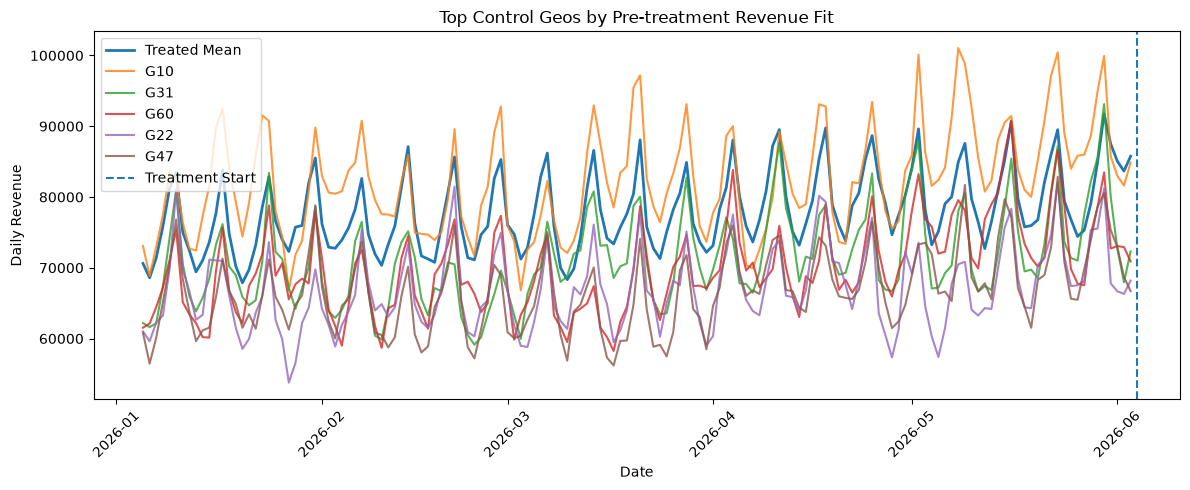

In [14]:
top_donors = donor_stats.head(5)["geo"].tolist()

plt.figure(figsize=(12, 5))
plt.plot(treated_daily.index, treated_daily, label="Treated Mean", linewidth=2)

for geo in top_donors:
    plt.plot(
        control_geo.index,
        control_geo[geo],
        label=geo,
        alpha=0.8
    )

plt.axvline(
    pd.Timestamp("2026-06-04"),
    linestyle="--",
    label="Treatment Start"
)

plt.title("Top Control Geos by Pre-treatment Revenue Fit")
plt.xlabel("Date")
plt.ylabel("Daily Revenue")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [16]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize

pre = panel[panel["post"] == 0]
post = panel[panel["post"] == 1]

treated_pre = pre[pre["treated"] == 1].groupby("date")["revenue"].mean()
control_pre = pre[pre["treated"] == 0].pivot(index="date", columns="geo", values="revenue")
treated_post = post[post["treated"] == 1].groupby("date")["revenue"].mean()
control_post = post[post["treated"] == 0].pivot(index="date", columns="geo", values="revenue")

donors = control_pre.columns.tolist()

# Normalize each geo by its pre-treatment mean for numerical stability.
treated_scale = treated_pre.mean()
control_scales = control_pre.mean()

y = (treated_pre / treated_scale).values
X = (control_pre / control_scales).values

def objective(w):
    return np.mean((y - X @ w) ** 2)

constraints = {"type": "eq", "fun": lambda w: np.sum(w) - 1}
bounds = [(0, 1)] * len(donors)
w0 = np.ones(len(donors)) / len(donors)

result = minimize(
    objective,
    w0,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
    options={"maxiter": 10000, "ftol": 1e-9}
)

print("Optimization:", result.success)
print("Message:", result.message)

if not result.success:
    raise RuntimeError(f"Synthetic control optimization failed: {result.message}")

weights = pd.Series(result.x, index=donors)
weights = weights[weights > 1e-4].sort_values(ascending=False)

print("\nNon-zero donor weights:")
print(weights.round(4))
print(f"\nWeight sum: {weights.sum():.6f}")

Optimization: True
Message: Optimization terminated successfully

Non-zero donor weights:
G25    0.0952
G54    0.0933
G30    0.0906
G24    0.0881
G08    0.0881
G21    0.0817
G17    0.0763
G48    0.0621
G57    0.0557
G02    0.0496
G36    0.0408
G42    0.0397
G04    0.0395
G22    0.0249
G40    0.0164
G19    0.0139
G05    0.0136
G58    0.0123
G43    0.0119
G52    0.0058
G33    0.0004
dtype: float64

Weight sum: 1.000000


In [17]:
synthetic_pre = control_pre[weights.index].values @ weights.values

pre_fit = pd.DataFrame({
    "actual_treated": treated_pre.values,
    "synthetic_treated": synthetic_pre
}, index=treated_pre.index)

pre_rmse = np.sqrt(
    np.mean((pre_fit["actual_treated"] - pre_fit["synthetic_treated"]) ** 2)
)

pre_mae = np.mean(
    np.abs(pre_fit["actual_treated"] - pre_fit["synthetic_treated"])
)

pre_corr = pre_fit["actual_treated"].corr(pre_fit["synthetic_treated"])

print(f"Pre-period RMSE: {pre_rmse:,.2f}")
print(f"Pre-period MAE:  {pre_mae:,.2f}")
print(f"Pre-period correlation: {pre_corr:.4f}")

Pre-period RMSE: 46,209.23
Pre-period MAE:  46,080.27
Pre-period correlation: 0.9563


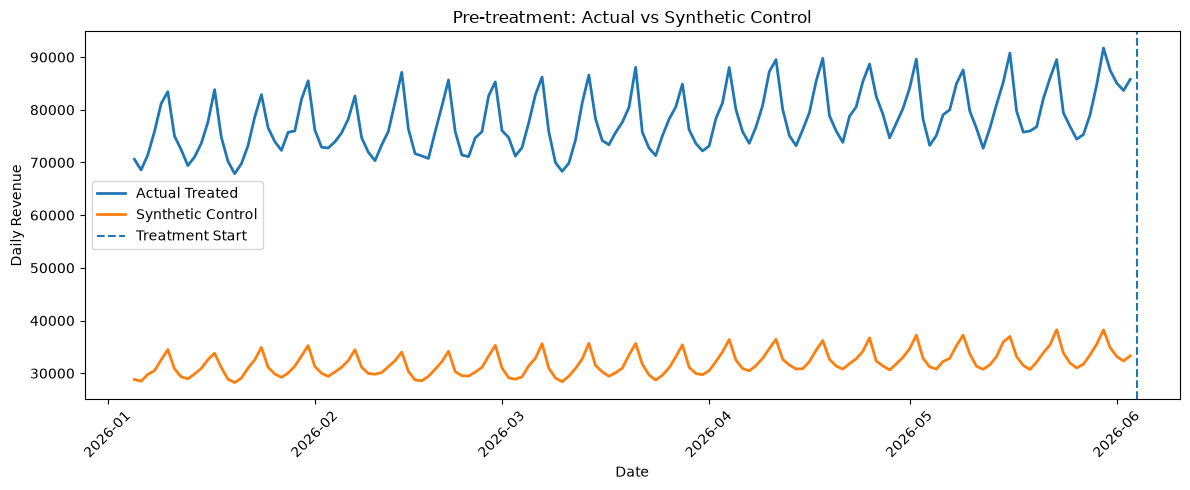

In [18]:
plt.figure(figsize=(12, 5))

plt.plot(
    treated_pre.index,
    treated_pre,
    label="Actual Treated",
    linewidth=2
)

plt.plot(
    pre_fit.index,
    pre_fit["synthetic_treated"],
    label="Synthetic Control",
    linewidth=2
)

plt.axvline(
    pd.Timestamp("2026-06-04"),
    linestyle="--",
    label="Treatment Start"
)

plt.title("Pre-treatment: Actual vs Synthetic Control")
plt.xlabel("Date")
plt.ylabel("Daily Revenue")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
# Reconstruct synthetic revenue on the treated group's original scale.
control_pre_norm = control_pre.div(control_pre.mean(axis=0), axis=1)
control_post_norm = control_post.div(control_pre.mean(axis=0), axis=1)

synthetic_pre = (
    control_pre_norm[weights.index].values @ weights.values
) * treated_scale

synthetic_post = (
    control_post_norm[weights.index].values @ weights.values
) * treated_scale

pre_fit = pd.DataFrame({
    "actual_treated": treated_pre,
    "synthetic_treated": synthetic_pre
}, index=treated_pre.index)

pre_rmse = np.sqrt(
    np.mean((pre_fit["actual_treated"] - pre_fit["synthetic_treated"]) ** 2)
)
pre_mae = np.mean(
    np.abs(pre_fit["actual_treated"] - pre_fit["synthetic_treated"])
)
pre_corr = pre_fit["actual_treated"].corr(pre_fit["synthetic_treated"])

print(f"Pre-period RMSE: {pre_rmse:,.2f}")
print(f"Pre-period MAE:  {pre_mae:,.2f}")
print(f"Pre-period correlation: {pre_corr:.4f}")

Pre-period RMSE: 1,593.13
Pre-period MAE:  1,269.07
Pre-period correlation: 0.9583


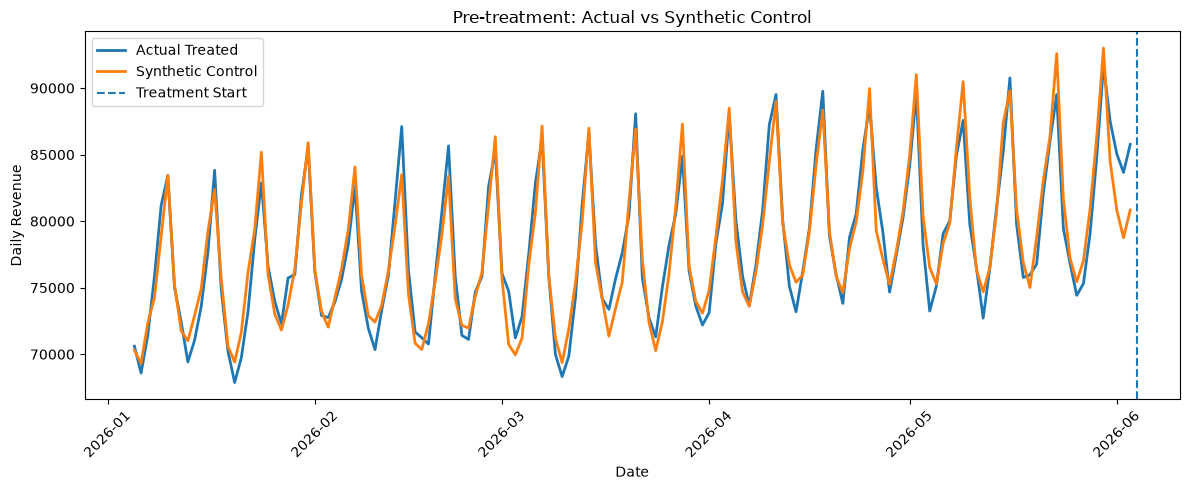

In [20]:
plt.figure(figsize=(12, 5))

plt.plot(
    treated_pre.index,
    treated_pre,
    label="Actual Treated",
    linewidth=2
)

plt.plot(
    pre_fit.index,
    pre_fit["synthetic_treated"],
    label="Synthetic Control",
    linewidth=2
)

plt.axvline(
    pd.Timestamp("2026-06-04"),
    linestyle="--",
    label="Treatment Start"
)

plt.title("Pre-treatment: Actual vs Synthetic Control")
plt.xlabel("Date")
plt.ylabel("Daily Revenue")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
pre_fit["error"] = pre_fit["actual_treated"] - pre_fit["synthetic_treated"]
pre_fit["abs_error"] = pre_fit["error"].abs()

print(pre_fit[["actual_treated", "synthetic_treated", "error"]].head(10).round(2))
print(f"\nMean actual revenue:    {pre_fit['actual_treated'].mean():,.2f}")
print(f"Mean synthetic revenue: {pre_fit['synthetic_treated'].mean():,.2f}")
print(f"Relative RMSE: {pre_rmse / pre_fit['actual_treated'].mean():.2%}")

            actual_treated  synthetic_treated    error
date                                                  
2026-01-05        70606.24           70302.55   303.69
2026-01-06        68584.32           69306.73  -722.41
2026-01-07        71424.07           72347.44  -923.37
2026-01-08        75843.97           74258.61  1585.36
2026-01-09        81167.57           78834.19  2333.37
2026-01-10        83436.48           83444.62    -8.14
2026-01-11        75026.42           75228.64  -202.22
2026-01-12        72419.50           71767.45   652.04
2026-01-13        69420.19           71003.64 -1583.45
2026-01-14        71047.18           72897.23 -1850.05

Mean actual revenue:    78,062.52
Mean synthetic revenue: 78,062.52
Relative RMSE: 2.04%


In [22]:
post_fit = pd.DataFrame({
    "actual_revenue": treated_post,
    "synthetic_revenue": synthetic_post
}, index=treated_post.index)

post_fit["incremental_revenue"] = (
    post_fit["actual_revenue"] - post_fit["synthetic_revenue"]
)

post_fit["relative_lift"] = (
    post_fit["incremental_revenue"] / post_fit["synthetic_revenue"]
)

print(post_fit.round(2))

print("\n--- Post-treatment estimate ---")
print(f"Mean daily incremental revenue: {post_fit['incremental_revenue'].mean():,.2f}")
print(f"Total incremental revenue:     {post_fit['incremental_revenue'].sum():,.2f}")
print(f"Mean relative lift:            {post_fit['relative_lift'].mean():.2%}")

            actual_revenue  synthetic_revenue  incremental_revenue  \
date                                                                 
2026-06-04        93960.69           84200.72              9759.97   
2026-06-05        97142.11           87677.70              9464.42   
2026-06-06       102361.12           91660.03             10701.09   
2026-06-07        92201.25           82338.49              9862.76   
2026-06-08        87876.68           78603.20              9273.49   
2026-06-09        88241.50           77979.02             10262.47   
2026-06-10        88190.40           80248.85              7941.56   
2026-06-11        94889.79           82872.24             12017.55   
2026-06-12       100280.97           89183.26             11097.71   
2026-06-13       106930.46           92762.83             14167.63   
2026-06-14        94935.68           84272.69             10662.99   
2026-06-15        92279.62           80246.75             12032.88   
2026-06-16        91

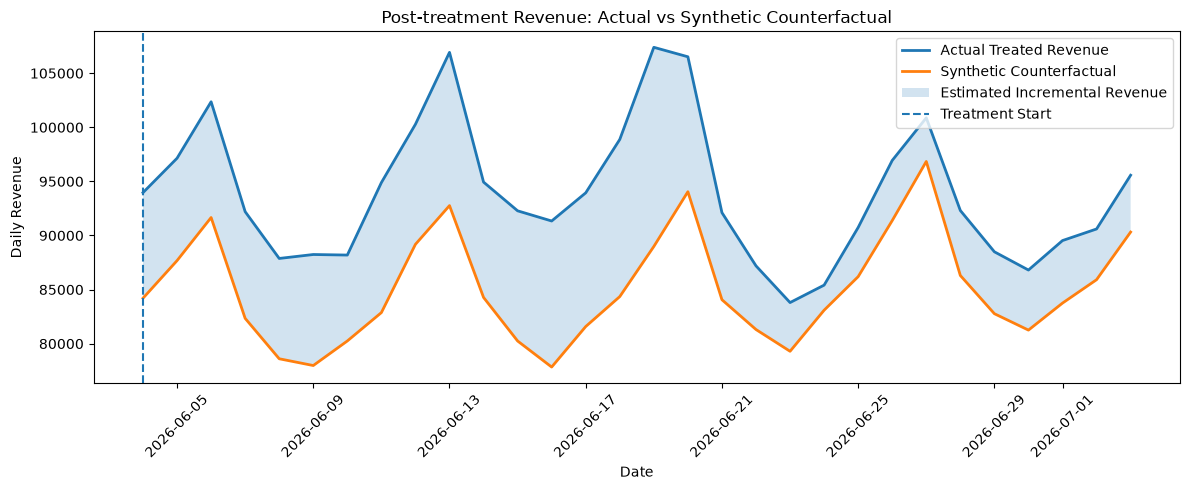

In [23]:
plt.figure(figsize=(12, 5))

plt.plot(
    post_fit.index,
    post_fit["actual_revenue"],
    label="Actual Treated Revenue",
    linewidth=2
)

plt.plot(
    post_fit.index,
    post_fit["synthetic_revenue"],
    label="Synthetic Counterfactual",
    linewidth=2
)

plt.fill_between(
    post_fit.index,
    post_fit["actual_revenue"],
    post_fit["synthetic_revenue"],
    alpha=0.2,
    label="Estimated Incremental Revenue"
)

plt.axvline(
    pd.Timestamp("2026-06-04"),
    linestyle="--",
    label="Treatment Start"
)

plt.title("Post-treatment Revenue: Actual vs Synthetic Counterfactual")
plt.xlabel("Date")
plt.ylabel("Daily Revenue")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

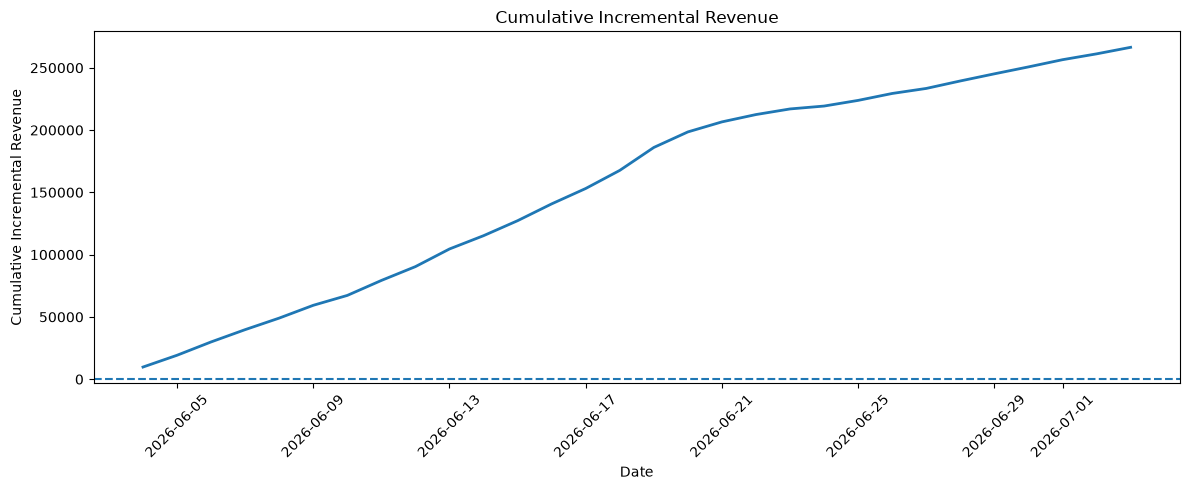

In [24]:
post_fit["cumulative_incremental"] = post_fit["incremental_revenue"].cumsum()

plt.figure(figsize=(12, 5))
plt.plot(
    post_fit.index,
    post_fit["cumulative_incremental"],
    linewidth=2
)

plt.axhline(0, linestyle="--")
plt.title("Cumulative Incremental Revenue")
plt.xlabel("Date")
plt.ylabel("Cumulative Incremental Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
treated_pre_spend = pre.loc[pre["treated"] == 1, "spend"].mean()
treated_post_spend = post.loc[post["treated"] == 1, "spend"].mean()

control_pre_spend = pre.loc[pre["treated"] == 0, "spend"].mean()
control_post_spend = post.loc[post["treated"] == 0, "spend"].mean()

treated_spend_change = treated_post_spend - treated_pre_spend
control_spend_change = control_post_spend - control_pre_spend
spend_did = treated_spend_change - control_spend_change

print(f"Treated pre-period spend:   ₹{treated_pre_spend:,.2f}")
print(f"Treated post-period spend:  ₹{treated_post_spend:,.2f}")
print(f"Treated spend change:       ₹{treated_spend_change:,.2f}")

print(f"\nControl pre-period spend:    ₹{control_pre_spend:,.2f}")
print(f"Control post-period spend:   ₹{control_post_spend:,.2f}")
print(f"Control spend change:        ₹{control_spend_change:,.2f}")

print(f"\nRelative spend change:       {treated_spend_change / treated_pre_spend:.2%}")
print(f"Spend DiD:                   ₹{spend_did:,.2f}")

Treated pre-period spend:   ₹9,342.76
Treated post-period spend:  ₹10,330.60
Treated spend change:       ₹987.83

Control pre-period spend:    ₹4,958.93
Control post-period spend:   ₹5,464.42
Control spend change:        ₹505.49

Relative spend change:       10.57%
Spend DiD:                   ₹482.34


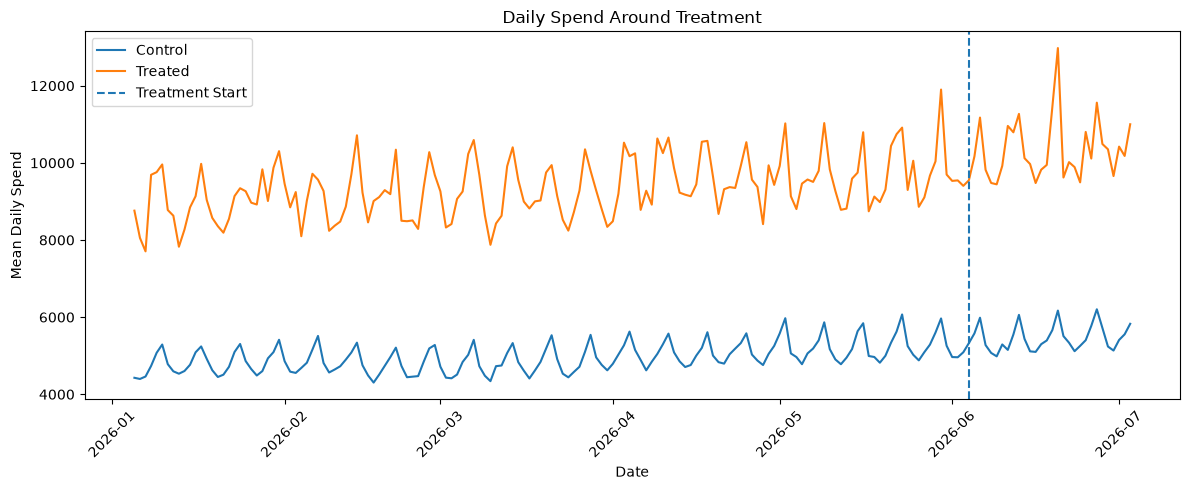

In [26]:
daily_spend = (
    panel.groupby(["date", "treated"])["spend"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 5))

for treated, label in [(0, "Control"), (1, "Treated")]:
    s = daily_spend[daily_spend["treated"] == treated]
    plt.plot(s["date"], s["spend"], label=label)

plt.axvline(
    pd.Timestamp("2026-06-04"),
    linestyle="--",
    label="Treatment Start"
)

plt.title("Daily Spend Around Treatment")
plt.xlabel("Date")
plt.ylabel("Mean Daily Spend")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
from sklearn.utils import check_random_state

rng = check_random_state(42)

all_control_geos = panel.loc[panel["treated"] == 0, "geo"].unique().tolist()
placebo_results = []

for i in range(100):
    placebo_geos = rng.choice(all_control_geos, size=6, replace=False).tolist()
    donor_geos = [g for g in all_control_geos if g not in placebo_geos]

    placebo_pre = (
        pre[pre["geo"].isin(placebo_geos)]
        .groupby("date")["revenue"]
        .mean()
    )

    placebo_post = (
        post[post["geo"].isin(placebo_geos)]
        .groupby("date")["revenue"]
        .mean()
    )

    donor_pre = (
        pre[pre["geo"].isin(donor_geos)]
        .pivot(index="date", columns="geo", values="revenue")
    )

    donor_post = (
        post[post["geo"].isin(donor_geos)]
        .pivot(index="date", columns="geo", values="revenue")
    )

    placebo_scale = placebo_pre.mean()
    donor_scales = donor_pre.mean()

    X = donor_pre.div(donor_scales, axis=1).values
    y = (placebo_pre / placebo_scale).values

    n_donors = len(donor_geos)
    w0 = np.ones(n_donors) / n_donors

    result = minimize(
        objective,
        w0,
        args=(),
        method="SLSQP",
        bounds=[(0, 1)] * n_donors,
        constraints={"type": "eq", "fun": lambda w: np.sum(w) - 1},
        options={"maxiter": 5000, "ftol": 1e-8}
    )

    if not result.success:
        continue

    weights_p = pd.Series(result.x, index=donor_geos)
    weights_p = weights_p[weights_p > 1e-4]

    donor_post_norm = donor_post.div(donor_scales, axis=1)

    synthetic_post_p = (
        donor_post_norm[weights_p.index].values @ weights_p.values
    ) * placebo_scale

    placebo_effect = (
        placebo_post.values - synthetic_post_p
    ).sum()

    placebo_results.append({
        "iteration": i,
        "placebo_geos": ",".join(placebo_geos),
        "effect": placebo_effect,
        "relative_effect": placebo_effect / placebo_pre.sum()
    })

placebo_df = pd.DataFrame(placebo_results)

print(f"Successful placebo runs: {len(placebo_df)}")
print("\nPlacebo cumulative effects:")
print(placebo_df["effect"].describe().round(2))

Successful placebo runs: 100

Placebo cumulative effects:
count      100.00
mean      -562.93
std      18535.82
min     -37955.08
25%     -14118.66
50%       -520.59
75%      13306.21
max      53629.56
Name: effect, dtype: float64


In [30]:
real_effect = post_fit["incremental_revenue"].sum()
real_relative_effect = real_effect / treated_pre.sum()

print(f"Real cumulative effect: {real_effect:,.2f}")
print(f"Real relative effect:   {real_relative_effect:.2%}")

print(f"\nPlacebo relative effect:")
print(placebo_df["relative_effect"].describe().round(4))

placebo_exceedance = (
    np.mean(
        np.abs(placebo_df["relative_effect"]) >= abs(real_relative_effect)
    )
)
placebo_p = (placebo_exceedance + 1) / (len(placebo_df) + 1)
print(f"\nPlacebo exceedance rate: {placebo_exceedance}/{len(placebo_df)}")
print(f"Empirical placebo p-value: {placebo_p:.4f}")

Real cumulative effect: 266,422.99
Real relative effect:   2.28%

Placebo relative effect:
count    100.0000
mean      -0.0002
std        0.0033
min       -0.0072
25%       -0.0025
50%       -0.0001
75%        0.0023
max        0.0074
Name: relative_effect, dtype: float64

Placebo exceedance rate: 0.0/100
Empirical placebo p-value: 0.0099


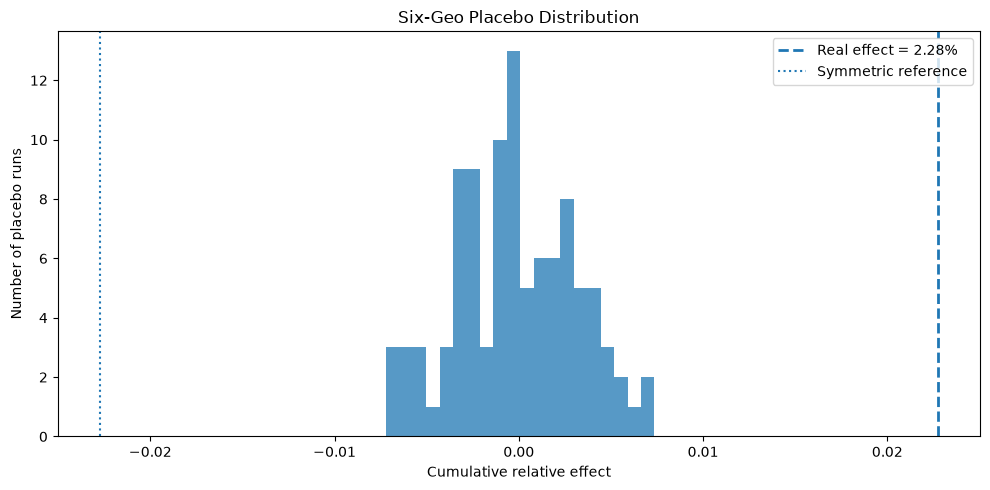

In [31]:
plt.figure(figsize=(10, 5))

plt.hist(
    placebo_df["relative_effect"],
    bins=20,
    alpha=0.75
)

plt.axvline(
    real_relative_effect,
    linestyle="--",
    linewidth=2,
    label=f"Real effect = {real_relative_effect:.2%}"
)

plt.axvline(
    -real_relative_effect,
    linestyle=":",
    label="Symmetric reference"
)

plt.xlabel("Cumulative relative effect")
plt.ylabel("Number of placebo runs")
plt.title("Six-Geo Placebo Distribution")
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
placebo_q05, placebo_q95 = np.quantile(
    placebo_df["effect"],
    [0.05, 0.95]
)

effect_lower = real_effect - placebo_q95
effect_upper = real_effect - placebo_q05

print(f"Real cumulative effect: ₹{real_effect:,.2f}")
print(f"90% uncertainty interval: ₹{effect_lower:,.2f} → ₹{effect_upper:,.2f}")
print(f"Placebo 5th percentile: ₹{placebo_q05:,.2f}")
print(f"Placebo 95th percentile: ₹{placebo_q95:,.2f}")

Real cumulative effect: ₹266,422.99
90% uncertainty interval: ₹237,778.37 → ₹294,463.41
Placebo 5th percentile: ₹-28,040.43
Placebo 95th percentile: ₹28,644.62


In [34]:
import statsmodels.formula.api as smf

did_model = smf.ols(
    "revenue ~ treated_post + C(geo) + C(date)",
    data=panel
).fit(
    cov_type="cluster",
    cov_kwds={"groups": panel["geo"]}
)

did_coef = did_model.params["treated_post"]
did_se = did_model.bse["treated_post"]

did_ci = did_model.conf_int(alpha=0.10).loc["treated_post"]

n_treated = panel.loc[panel["treated"] == 1, "geo"].nunique()
n_post_days = panel.loc[panel["post"] == 1, "date"].nunique()

did_total = did_coef * n_treated * n_post_days
did_total_lower = did_ci[0] * n_treated * n_post_days
did_total_upper = did_ci[1] * n_treated * n_post_days

print("=== Two-Way Fixed Effects DiD ===")
print(f"Daily treatment effect / treated geo: ₹{did_coef:,.2f}")
print(f"Standard error:                       ₹{did_se:,.2f}")
print(f"90% daily CI:                         ₹{did_ci[0]:,.2f} → ₹{did_ci[1]:,.2f}")
print()
print(f"30-day total DiD estimate:            ₹{did_total:,.2f}")
print(f"90% total CI:                         ₹{did_total_lower:,.2f} → ₹{did_total_upper:,.2f}")

=== Two-Way Fixed Effects DiD ===
Daily treatment effect / treated geo: ₹11,847.65
Standard error:                       ₹4,462.48
90% daily CI:                         ₹4,507.53 → ₹19,187.77

30-day total DiD estimate:            ₹2,132,576.73
90% total CI:                         ₹811,354.84 → ₹3,453,798.63


In [35]:
comparison = pd.DataFrame({
    "method": ["Synthetic Control", "Two-Way Fixed Effects DiD"],
    "estimate": [real_effect, did_total],
    "lower_90": [effect_lower, did_total_lower],
    "upper_90": [effect_upper, did_total_upper]
})

print(comparison.round(2).to_string(index=False))

                   method   estimate  lower_90   upper_90
        Synthetic Control  266422.99 237778.37  294463.41
Two-Way Fixed Effects DiD 2132576.73 811354.84 3453798.63


In [36]:
pre_only = panel[panel["post"] == 0].copy()
pre_only["days_since_start"] = (
    pre_only["date"] - pre_only["date"].min()
).dt.days

pretrend_model = smf.ols(
    "revenue ~ treated + days_since_start + treated:days_since_start + C(geo) + C(date)",
    data=pre_only
).fit(
    cov_type="cluster",
    cov_kwds={"groups": pre_only["geo"]}
)

coef = pretrend_model.params["treated:days_since_start"]
ci = pretrend_model.conf_int(alpha=0.10).loc["treated:days_since_start"]

print("=== Pre-treatment Trend Test ===")
print(f"Treated × time coefficient: ₹{coef:,.2f} per day")
print(f"90% CI: ₹{ci[0]:,.2f} → ₹{ci[1]:,.2f}")
print(f"P-value: {pretrend_model.pvalues['treated:days_since_start']:.4f}")

=== Pre-treatment Trend Test ===
Treated × time coefficient: ₹23.79 per day
90% CI: ₹0.50 → ₹47.09
P-value: 0.0930


/var/folders/yk/975v12617wjby1k2n4krpjp00000gn/T/ipykernel_89979/2648100363.py:9: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ).fit(


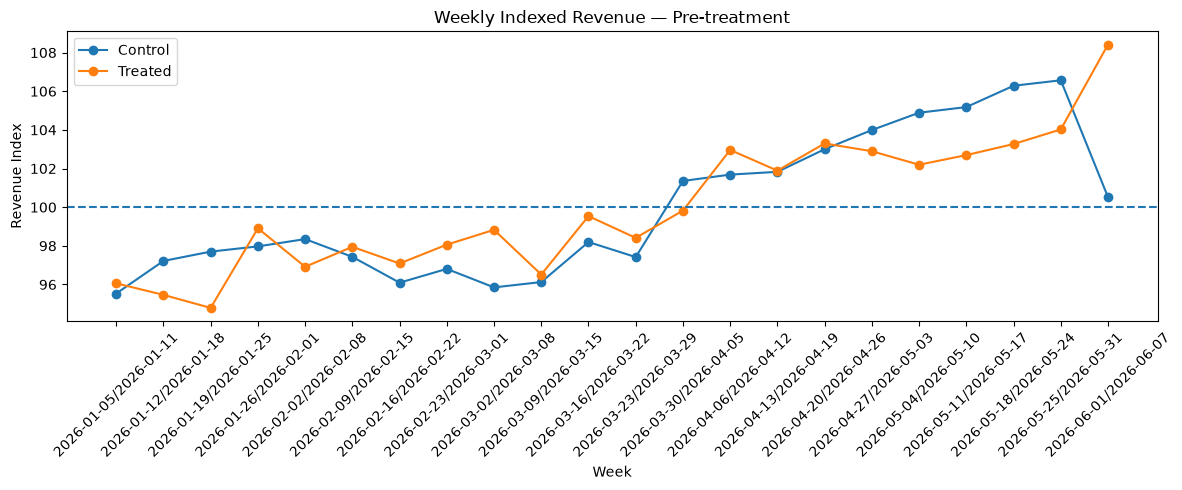

In [37]:
weekly = (
    pre_only.assign(week=pre_only["date"].dt.to_period("W").astype(str))
    .groupby(["week", "treated"])["revenue"]
    .mean()
    .reset_index()
)

baseline = (
    weekly.groupby("treated")["revenue"]
    .mean()
    .rename("baseline")
)

weekly = weekly.merge(baseline, on="treated")
weekly["indexed_revenue"] = weekly["revenue"] / weekly["baseline"] * 100

plt.figure(figsize=(12, 5))

for treated, label in [(0, "Control"), (1, "Treated")]:
    s = weekly[weekly["treated"] == treated]
    plt.plot(s["week"], s["indexed_revenue"], marker="o", label=label)

plt.axhline(100, linestyle="--")
plt.title("Weekly Indexed Revenue — Pre-treatment")
plt.xlabel("Week")
plt.ylabel("Revenue Index")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [38]:
pre_weekly = panel[panel["post"] == 0].copy()
pre_weekly["week"] = pre_weekly["date"].dt.to_period("W").dt.start_time

weekly_geo = (
    pre_weekly
    .groupby(["geo", "treated", "week"], as_index=False)["revenue"]
    .mean()
)

weekly_geo["week_index"] = (
    weekly_geo["week"] - weekly_geo["week"].min()
).dt.days / 7

pretrend_model = smf.ols(
    "revenue ~ treated:week_index + C(geo)",
    data=weekly_geo
).fit(
    cov_type="cluster",
    cov_kwds={"groups": weekly_geo["geo"]}
)

coef = pretrend_model.params["treated:week_index"]
ci = pretrend_model.conf_int(alpha=0.10).loc["treated:week_index"]
pval = pretrend_model.pvalues["treated:week_index"]

print("=== Weekly Pre-treatment Trend Test ===")
print(f"Treated × week coefficient: ₹{coef:,.2f} per week")
print(f"90% CI: ₹{ci[0]:,.2f} → ₹{ci[1]:,.2f}")
print(f"P-value: {pval:.4f}")

=== Weekly Pre-treatment Trend Test ===
Treated × week coefficient: ₹379.24 per week
90% CI: ₹194.03 → ₹564.46
P-value: 0.0008


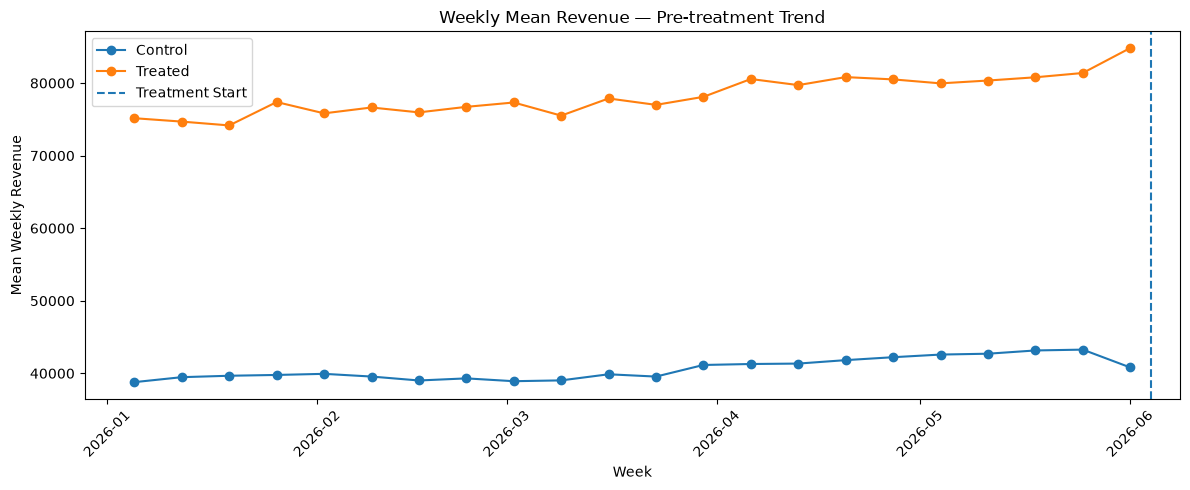

In [39]:
trend_plot = (
    weekly_geo
    .groupby(["week", "treated"])["revenue"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 5))

for treated, label in [(0, "Control"), (1, "Treated")]:
    s = trend_plot[trend_plot["treated"] == treated]
    plt.plot(
        s["week"],
        s["revenue"],
        marker="o",
        label=label
    )

plt.axvline(
    pd.Timestamp("2026-06-04"),
    linestyle="--",
    label="Treatment Start"
)

plt.title("Weekly Mean Revenue — Pre-treatment Trend")
plt.xlabel("Week")
plt.ylabel("Mean Weekly Revenue")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [42]:
sensitivity_results = []

for removed_geo in weights.index:
    donor_geos = [g for g in donors if g != removed_geo]

    X_s = control_pre[donor_geos].div(
        control_pre[donor_geos].mean(axis=0), axis=1
    ).values

    y_s = (treated_pre / treated_scale).values

    def sensitivity_objective(w):
        return np.mean((y_s - X_s @ w) ** 2)

    n = len(donor_geos)
    w0_s = np.ones(n) / n

    result_s = minimize(
        sensitivity_objective,
        w0_s,
        method="SLSQP",
        bounds=[(0, 1)] * n,
        constraints={"type": "eq", "fun": lambda w: np.sum(w) - 1},
        options={"maxiter": 5000, "ftol": 1e-8}
    )

    if not result_s.success:
        continue

    w_s = pd.Series(result_s.x, index=donor_geos)
    w_s = w_s[w_s > 1e-4]

    post_norm_s = control_post[donor_geos].div(
        control_pre[donor_geos].mean(axis=0), axis=1
    )

    synthetic_post_s = (
        post_norm_s[w_s.index].values @ w_s.values
    ) * treated_scale

    effect_s = (
        treated_post.values - synthetic_post_s
    ).sum()

    pre_norm_s = control_pre[donor_geos].div(
        control_pre[donor_geos].mean(axis=0), axis=1
    )

    synthetic_pre_s = (
        pre_norm_s[w_s.index].values @ w_s.values
    ) * treated_scale

    rmse_s = np.sqrt(
        np.mean(
            (treated_pre.values - synthetic_pre_s) ** 2
        )
    )

    sensitivity_results.append({
        "removed_geo": removed_geo,
        "effect": effect_s,
        "pre_rmse": rmse_s
    })

sensitivity_df = pd.DataFrame(sensitivity_results)

print(sensitivity_df.round(2).to_string(index=False))

print("\n=== Sensitivity Summary ===")
print(f"Baseline effect: ₹{real_effect:,.2f}")
print(f"Min effect:      ₹{sensitivity_df['effect'].min():,.2f}")
print(f"Max effect:      ₹{sensitivity_df['effect'].max():,.2f}")
print(f"Mean effect:     ₹{sensitivity_df['effect'].mean():,.2f}")
print(f"Std effect:      ₹{sensitivity_df['effect'].std():,.2f}")

removed_geo    effect  pre_rmse
        G25 268559.90   1616.15
        G54 270545.15   1615.92
        G30 260928.59   1615.22
        G24 265850.55   1612.90
        G08 256472.18   1620.23
        G21 260375.89   1614.47
        G17 268514.35   1608.78
        G48 267667.04   1604.31
        G57 275650.59   1604.28
        G02 262813.28   1600.98
        G36 263443.26   1599.55
        G42 264978.69   1599.07
        G04 263759.07   1598.32
        G22 266020.31   1594.76
        G40 267018.07   1594.13
        G19 269346.34   1594.00
        G05 265822.86   1593.91
        G58 265399.61   1594.00
        G43 263994.93   1593.87
        G52 266391.35   1593.62
        G33 265502.45   1593.50

=== Sensitivity Summary ===
Baseline effect: ₹266,422.99
Min effect:      ₹256,472.18
Max effect:      ₹275,650.59
Mean effect:     ₹265,669.26
Std effect:      ₹3,969.29


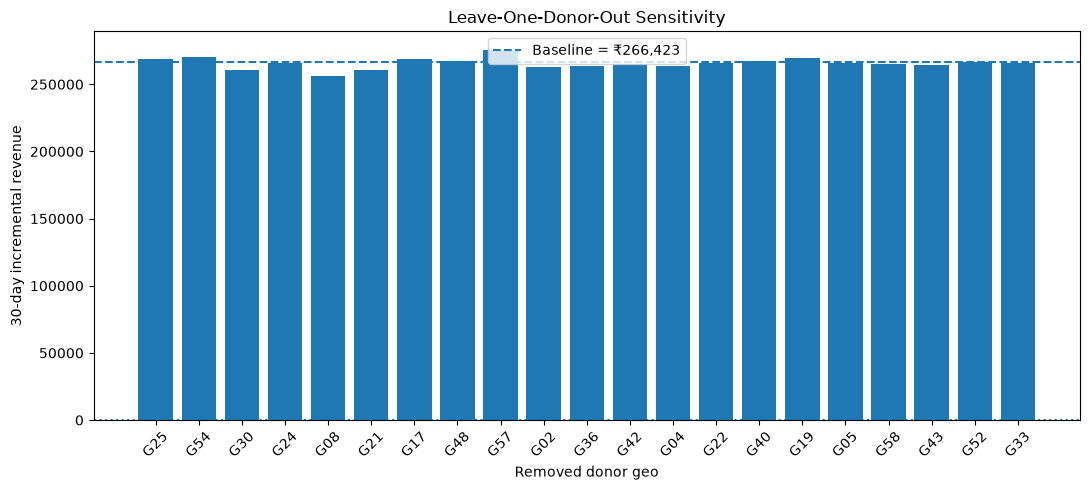

In [43]:
plt.figure(figsize=(11, 5))

plt.bar(
    sensitivity_df["removed_geo"],
    sensitivity_df["effect"]
)

plt.axhline(
    real_effect,
    linestyle="--",
    label=f"Baseline = ₹{real_effect:,.0f}"
)

plt.axhline(0, linestyle=":")

plt.title("Leave-One-Donor-Out Sensitivity")
plt.xlabel("Removed donor geo")
plt.ylabel("30-day incremental revenue")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [44]:
def assign_trust_state(
    point_estimate,
    interval_low,
    interval_high,
    placebo_p_value,
    pre_rmse_relative,
    sensitivity_min,
    sensitivity_max,
    did_estimate,
    did_parallel_trends_valid,
):
    """
    Deterministic Trust State rules for Part B.

    trusted:
        Positive effect with a non-zero 90% interval, strong pre-fit,
        stable magnitude, and no material estimator disagreement.

    directionally_trusted:
        Direction is robust, but magnitude has meaningful model dependence.

    magnitude_uncertain:
        Direction is supported, but magnitude is unstable.

    not_trusted:
        Direction itself is not reliably supported.
    """

    direction_supported = (
        point_estimate > 0
        and interval_low > 0
        and placebo_p_value < 0.10
        and sensitivity_min > 0
    )

    fit_good = pre_rmse_relative <= 0.05

    sensitivity_ratio = (
        (sensitivity_max - sensitivity_min)
        / abs(point_estimate)
    )

    magnitude_stable = sensitivity_ratio <= 0.20

    estimator_disagreement = (
        did_parallel_trends_valid
        and abs(did_estimate - point_estimate)
        / abs(point_estimate)
        > 0.50
    )

    if not direction_supported:
        return "not_trusted"

    if not magnitude_stable:
        return "magnitude_uncertain"

    if fit_good and not estimator_disagreement:
        return "trusted"

    return "directionally_trusted"

In [45]:
trust_state = assign_trust_state(
    point_estimate=real_effect,
    interval_low=effect_lower,
    interval_high=effect_upper,
    placebo_p_value=0.0099,
    pre_rmse_relative=0.0204,
    sensitivity_min=sensitivity_df["effect"].min(),
    sensitivity_max=sensitivity_df["effect"].max(),
    did_estimate=did_total,
    did_parallel_trends_valid=False,
)

print("Trust State:", trust_state)

Trust State: trusted
